In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator

# configurações de estilo padronizadas
sns.set_theme(style="whitegrid")
paleta_cores = {'Crítico': '#d9534f', 'alto': '#f0ad4e', 'médio': '#5bc0de', 'baixo': '#5cb85c', 'mínimo': '#a9a9a9'}
nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# carregar dataset sintético
input_path = '../dados_saida/dataset_sintetico_stress_test.csv'
try:
    df_sintetico = pd.read_csv(input_path)
    print(f"Dataset sintético carregado com {len(df_sintetico)} registros!")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em {input_path}")

Dataset sintético carregado com 101000 registros!


In [22]:
# cálculo da severidade ponderada (fase 1)
pesos = {'cvss': 0.3, 'epss': 0.3, 'ncs': 0.2, 'ppsi': 0.1, 'impacto': 0.1}

# normalização para o cálculo ponderado
df_sintetico['cvss_norm'] = df_sintetico['cvss'] / 10.0
df_sintetico['ncs_norm'] = df_sintetico['ncs'] / 10.0

df_sintetico['severidade_ponderada'] = (
    df_sintetico['cvss_norm'] * pesos['cvss'] +
    df_sintetico['epss'] * pesos['epss'] +
    df_sintetico['ncs_norm'] * pesos['ncs'] +
    df_sintetico['ppsi'] * pesos['ppsi'] +
    df_sintetico['impacto'] * pesos['impacto']
)

# definindo dimensões para clustering: epss (técnico) e ncs (negócio)
# o epss já está em [0,1]. normalizamos o ncs para a mesma escala.
scaler_m = MinMaxScaler()
df_sintetico['ncs_normalizado'] = scaler_m.fit_transform(df_sintetico[['ncs']])

X_cluster = df_sintetico[['epss', 'ncs_normalizado']]
scaler_s = StandardScaler()
X_scaled = scaler_s.fit_transform(X_cluster)

print("Resumo estatístico das dimensões de clustering:")
display(X_cluster.describe())

Resumo estatístico das dimensões de clustering:


,epss,ncs_normalizado
count,101000.000000,101000.000000
mean,0.294885,0.082091
std,0.260228,0.078979
min,0.000100,0.000000
25%,0.043867,0.043270
50%,0.257692,0.077949
75%,0.471368,0.112496
max,0.990000,1.000000


Taxonomia Institucional TCU (k=5).


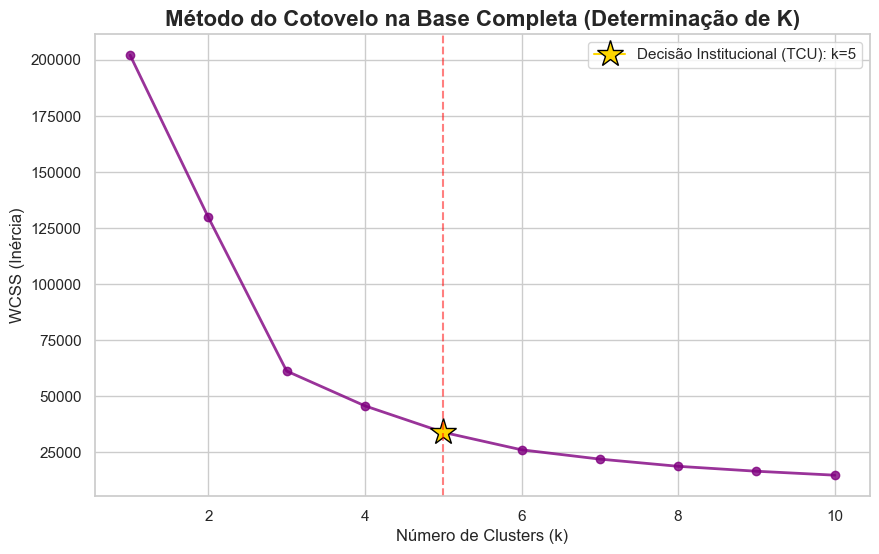

In [31]:
# --- método do cotovelo otimizado (base completa) ---
# para evitar o efeito "aleatório" de amostras, rodaremos o wcss na base inteira (x_scaled).
# como são apenas 100k registros e max k=10, o processamento será rápido e o resultado determinístico.

from kneed import KneeLocator

wcss = []
k_range = range(1, 11)

for i in k_range:
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    # rodando na base inteira para zerar distorções amostrais
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# identificação dinâmica do cotovelo
kn = KneeLocator(k_range, wcss, curve='convex', direction='decreasing', S=0)
k_detectado = kn.elbow
k_ideal = 5  # forçando k=5 baseado no acórdão tcu

print(f"Taxonomia Institucional TCU (k={k_ideal}).")

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='purple', alpha=0.8, linewidth=2)
plt.title('Método do Cotovelo na Base Completa (Determinação de K)', fontsize=16, weight='bold')


# marcar k institucional (tcu)
plt.plot(k_ideal, wcss[k_ideal-1], marker='*', markersize=20, color='gold', markeredgecolor='black', label=f'Decisão Institucional (TCU): k={k_ideal}')
plt.axvline(x=k_ideal, color='red', linestyle='--', alpha=0.5)

plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.legend()
plt.show()


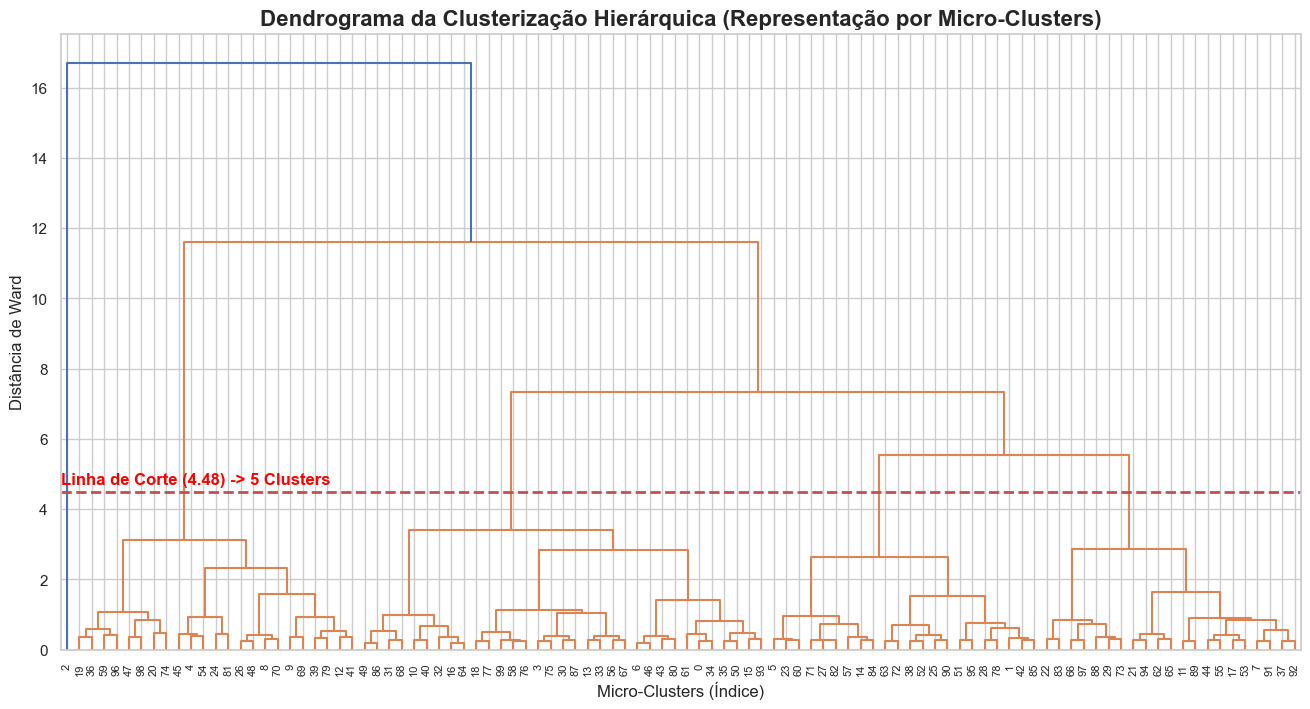

In [24]:
# --- dendrograma otimizado para larga escala (micro-clusters) ---
# como amostrar aleatoriamente 100k linhas gera ruído visual (outliers distorcem o ward),
# a literatura recomenda rodar um k-means com muitos clusters (ex: 100 micro-clusters) 
# e gerar o dendrograma dos centroides. isso reflete a estrutura global fielmente.

from sklearn.cluster import KMeans

# 1. gerar 100 micro-clusters representativos de toda a base de 100k
kmeans_micro = KMeans(n_clusters=100, random_state=42, n_init=10)
kmeans_micro.fit(X_scaled)
micro_centroides = kmeans_micro.cluster_centers_

# 2. calcular a distância (ward) apenas entre os 100 micro-centroides
Z = linkage(micro_centroides, method='ward')

# 3. plotagem do dendrograma
plt.figure(figsize=(16, 8))
ax = plt.gca()

# como temos exatamente 100 folhas, não precisamos truncar, é possível ver a árvore completa
dendrogram(Z, p=100, truncate_mode='lastp', show_leaf_counts=True, ax=ax, 
           leaf_rotation=90, leaf_font_size=8)

# 4. encontrar a linha de corte matemática exata para 5 clusters
# a matriz z possui n-1 linhas. 
# z[-1] é a última fusão (resta 1 cluster). z[-4] é a fusão que deixa 4 clusters. z[-5] deixa 5.
# para ter 5 clusters, a linha de corte deve estar entre z[-5, 2] e z[-4, 2]
altura_de_corte = (Z[-5, 2] + Z[-4, 2]) / 2

ax.axhline(y=altura_de_corte, color='r', linestyle='--', linewidth=2)
ax.text(x=0, y=altura_de_corte*1.05, s=f'Linha de Corte ({altura_de_corte:.2f}) -> 5 Clusters', color='red', fontweight='bold', fontsize=12)

plt.title('Dendrograma da Clusterização Hierárquica (Representação por Micro-Clusters)', fontsize=16, weight='bold')
plt.xlabel('Micro-Clusters (Índice)')
plt.ylabel('Distância de Ward')
plt.show()


In [25]:
kmeans_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
df_sintetico['cluster'] = kmeans_final.fit_predict(X_scaled)

# ordenação dos clusters por severidade para garantir nomes corretos
centroides = kmeans_final.cluster_centers_
# score de severidade simplificado para ordenação: soma das dimensões normalizadas
severidade_clusters = centroides.sum(axis=1)
sorted_clusters = np.argsort(severidade_clusters)[::-1] # do maior para o menor

mapa_perfis = {sorted_clusters[i]: nomes_perfis[i] for i in range(len(nomes_perfis))}
df_sintetico['PRP'] = df_sintetico['cluster'].map(mapa_perfis)

print("Classificação de risco institucional (PRP) concluída.")

Classificação de risco institucional (PRP) concluída.


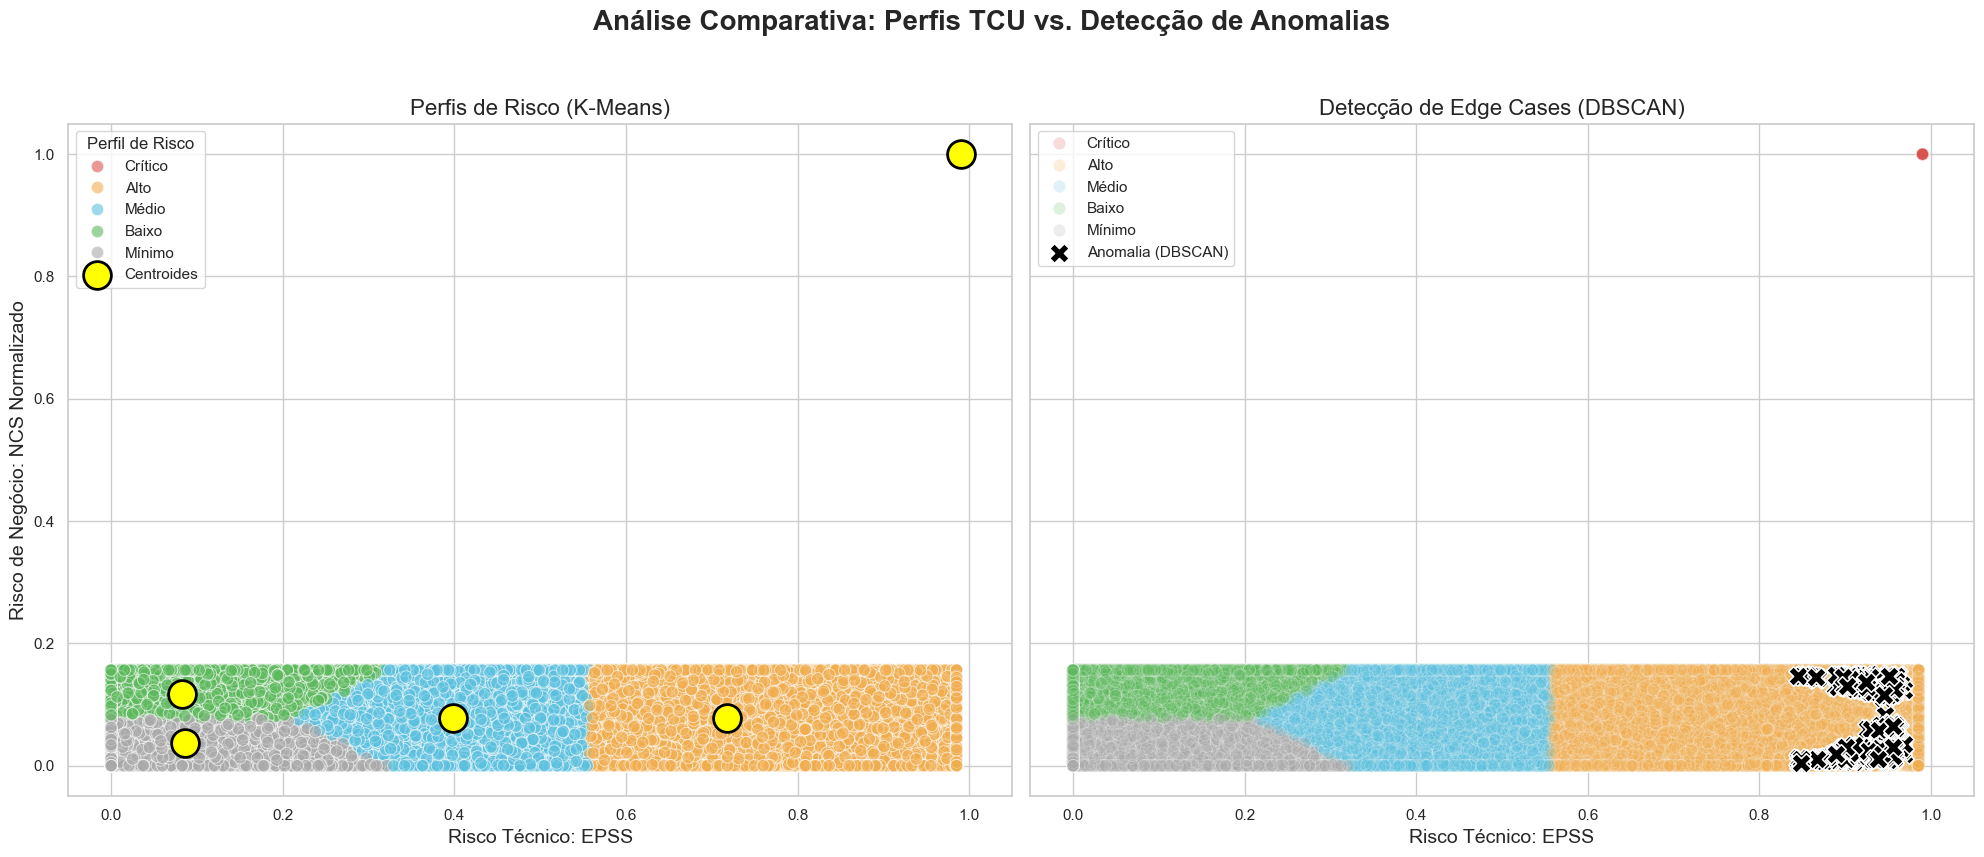

Quantidade de Outliers identificados: 263


In [26]:
# --- 6. comparação lado a lado: correção de escala dos centroides ---

# 1. configurações de estilo
paleta_cores = {'Crítico': '#d9534f', 'alto': '#f0ad4e', 'médio': '#5bc0de', 'baixo': '#5cb85c', 'mínimo': '#a9a9a9'}
ordem_hue = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# 2. dbscan (ajustado para a escala de x_cluster)
dbscan = DBSCAN(eps=0.05, min_samples=15)
df_sintetico['is_outlier'] = (dbscan.fit_predict(X_scaled) == -1)

# 3. correção dos centroides: 
# calcular as médias reais de cada cluster para plotagem correta
# isso garante que o ponto amarelo caia exatamente sobre a massa de dados
centroides_plot = df_sintetico.groupby('PRP')[['epss', 'ncs_normalizado']].mean().values

fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharex=True, sharey=True)
fig.suptitle('Análise Comparativa: Perfis TCU vs. Detecção de Anomalias', fontsize=20, weight='bold')

# --- gráfico 1: k-means (prp) ---
ax1 = axes[0]
sns.scatterplot(data=df_sintetico, x='epss', y='ncs_normalizado', hue='PRP', 
                hue_order=ordem_hue, palette=paleta_cores, s=80, alpha=0.6, ax=ax1)

# plotando os centroides calculados na escala real (0 a 1)
ax1.scatter(centroides_plot[:, 0], centroides_plot[:, 1], 
            s=400, c='yellow', marker='o', edgecolor='black', linewidth=2, label='Centroides', zorder=5)

ax1.set_title('Perfis de Risco (K-Means)', fontsize=16)
ax1.set_xlabel('Risco Técnico: EPSS', fontsize=14)
ax1.set_ylabel('Risco de Negócio: NCS Normalizado', fontsize=14)
ax1.set_xlim(-0.05, 1.05) # trava o eixo entre 0 e 1
ax1.set_ylim(-0.05, 1.05) # trava o eixo entre 0 e 1
ax1.legend(title='Perfil de Risco', loc='upper left')

# --- gráfico 2: dbscan outliers ---
ax2 = axes[1]
# pontos regulares (com transparência para destacar o outlier)
sns.scatterplot(data=df_sintetico[~df_sintetico['is_outlier']], x='epss', y='ncs_normalizado', 
                hue='PRP', hue_order=ordem_hue, palette=paleta_cores, s=80, alpha=0.2, ax=ax2)

# outliers com 'x' preto
if df_sintetico['is_outlier'].any():
    sns.scatterplot(data=df_sintetico[df_sintetico['is_outlier']], x='epss', y='ncs_normalizado', 
                    color='black', marker='X', s=200, label='Anomalia (DBSCAN)', ax=ax2, zorder=10)

ax2.set_title('Detecção de Edge Cases (DBSCAN)', fontsize=16)
ax2.set_xlabel('Risco Técnico: EPSS', fontsize=14)
ax2.set_ylabel('')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Quantidade de Outliers identificados: {df_sintetico['is_outlier'].sum()}")


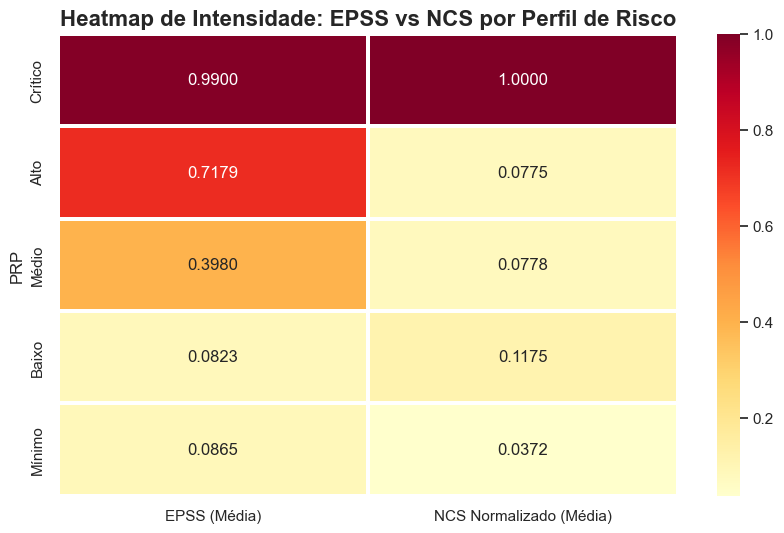


--- Correlação Estatística (Stress Test) ---


,epss,ncs_normalizado,severidade_ponderada
epss,1.000000,0.153989,0.966169
ncs_normalizado,0.153989,1.000000,0.173549
severidade_ponderada,0.966169,0.173549,1.000000


In [27]:
tabela_perfis = df_sintetico.groupby('PRP')[['epss', 'ncs_normalizado']].mean().reindex(nomes_perfis)
tabela_perfis.columns = ['EPSS (Média)', 'NCS Normalizado (Média)']

plt.figure(figsize=(10, 6))
sns.heatmap(tabela_perfis, annot=True, cmap='YlOrRd', fmt=".4f", linewidths=1.5)
plt.title('Heatmap de Intensidade: EPSS vs NCS por Perfil de Risco', fontsize=16, weight='bold')
plt.show()

print("\n--- Correlação Estatística (Stress Test) ---")
display(df_sintetico[['epss', 'ncs_normalizado', 'severidade_ponderada']].corr())

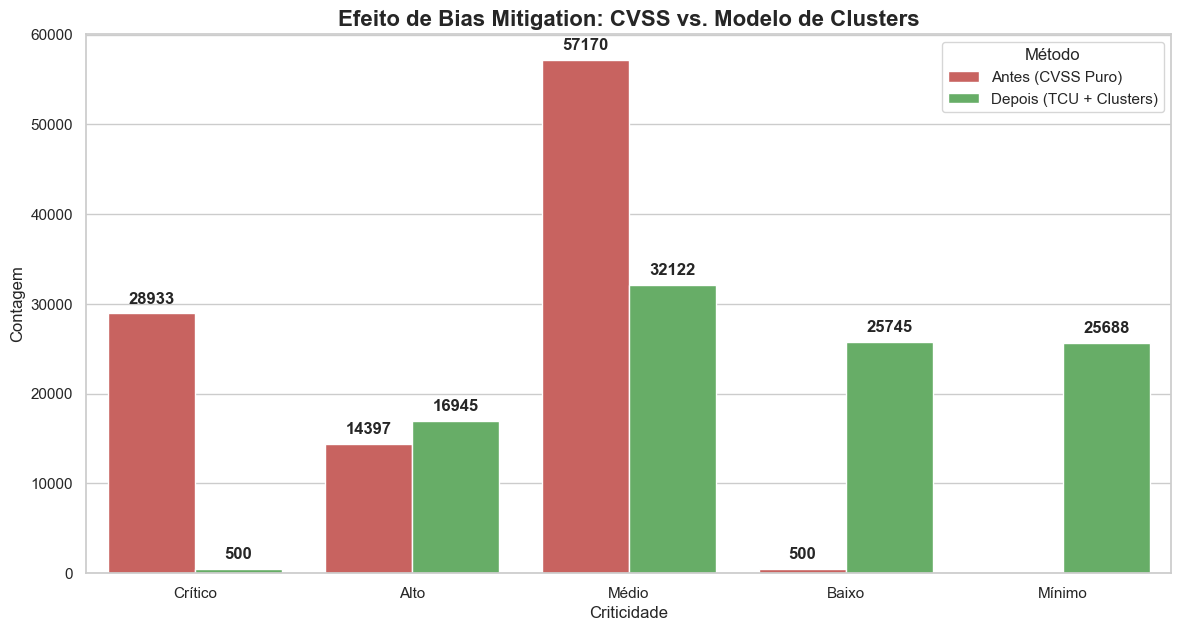

In [28]:
# padronização de nomes para o gráfico
mapa_cvss = {'CRITICAL': 'Crítico', 'HIGH': 'Alto', 'MEDIUM': 'Médio', 'LOW': 'Baixo'}
df_sintetico['cvss_clean'] = df_sintetico['severity'].str.upper().map(mapa_cvss).fillna('Mínimo')

dados_antes = df_sintetico['cvss_clean'].value_counts().reset_index()
dados_antes.columns = ['Criticidade', 'Contagem']
dados_antes['Método'] = 'Antes (CVSS Puro)'

dados_depois = df_sintetico['PRP'].value_counts().reset_index()
dados_depois.columns = ['Criticidade', 'Contagem']
dados_depois['Método'] = 'Depois (TCU + Clusters)'

df_comp = pd.concat([dados_antes, dados_depois])

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_comp, x='Criticidade', y='Contagem', hue='Método', order=nomes_perfis, 
                 palette={'Antes (CVSS Puro)': '#d9534f', 'depois (tcu + clusters)': '#5cb85c'})

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.title('Efeito de Bias Mitigation: CVSS vs. Modelo de Clusters', fontsize=16, weight='bold')
plt.show()

In [29]:
output_dir = '2_resultados'
os.makedirs(output_dir, exist_ok=True)
df_sintetico.to_csv(os.path.join(output_dir, 'stress_test_finalizado.csv'), index=False)
print("Modelagem de Stress Test Concluída e Exportada!")

Modelagem de Stress Test Concluída e Exportada!
